Dimensi dataset: 469 baris, 40 kolom

Statistik Deskriptif Kolom Sampah Per Tahun:
 tahun  count          mean    median        max
  2008      0           NaN       NaN        NaN
  2009      0           NaN       NaN        NaN
  2010      0           NaN       NaN        NaN
  2011      0           NaN       NaN        NaN
  2012      0           NaN       NaN        NaN
  2013      0           NaN       NaN        NaN
  2014      0           NaN       NaN        NaN
  2015     27 510334.567037 293210.71 2032364.07
  2016     27 514567.663333 295533.32 2044607.23
  2017     27 521209.988889 298488.65 2075276.34
  2018     27    574.290741    295.53    2294.65
  2019     27    625.956667    481.96    2127.70
  2020     27    653.857037    661.72    2173.05
  2021     27    414.418889    283.34    1430.04
  2022     27    394.173704    311.89    1573.44
  2023     27    175.825852     72.78     554.11
  2024      0           NaN       NaN        NaN
  2025      0           NaN       N

C:\Users\Hakim\AppData\Local\Temp\ipykernel_15612\2440960508.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tahun', y='jumlah_sampah_ton_per_hari', palette='Set3')


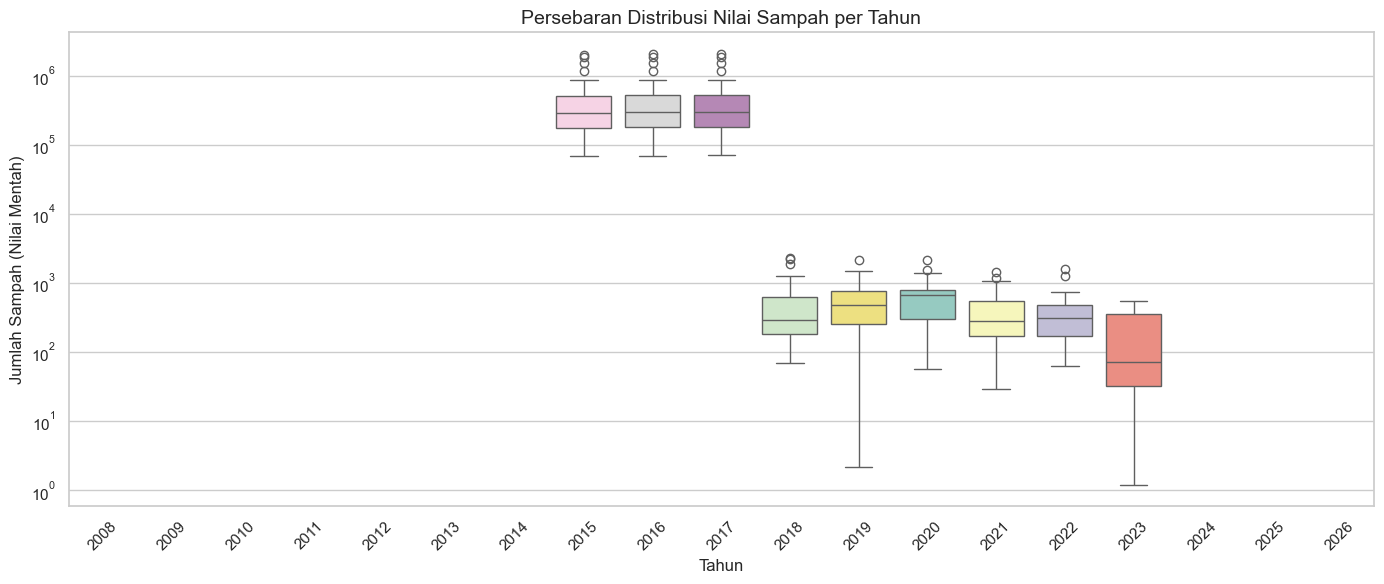

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_excel("flood-analytics-jabar.xlsx")
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")


sampah_yearly = df.groupby('tahun')['jumlah_sampah_ton_per_hari'].agg(['count', 'mean', 'median', 'max']).reset_index()
print("Statistik Deskriptif Kolom Sampah Per Tahun:")
print(sampah_yearly.to_string(index=False))
print("\n")
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='tahun', y='jumlah_sampah_ton_per_hari', palette='Set3')
plt.title("Persebaran Distribusi Nilai Sampah per Tahun", fontsize=14)
plt.xlabel("Tahun")
plt.ylabel("Jumlah Sampah (Nilai Mentah)")
plt.xticks(rotation=45)
plt.yscale('log') 
plt.tight_layout()
plt.show()




Total baris data           : 469
Jumlah baris bernilai 0    : 47 (10.02%)
Jumlah baris bernilai NULL : 91 (19.40%)




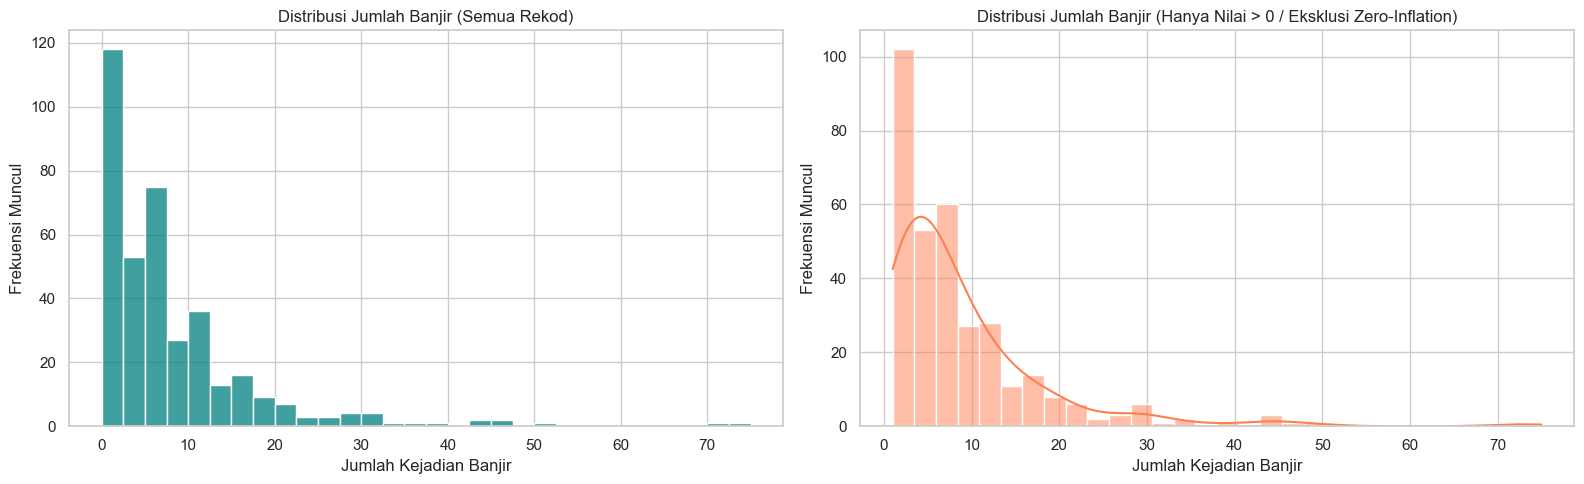

In [7]:
total_rows = len(df)
zero_banjir_count = (df['jumlah_banjir'] == 0).sum()
null_banjir_count = df['jumlah_banjir'].isnull().sum()

print(f"Total baris data           : {total_rows}")
print(f"Jumlah baris bernilai 0    : {zero_banjir_count} ({zero_banjir_count/total_rows*100:.2f}%)")
print(f"Jumlah baris bernilai NULL : {null_banjir_count} ({null_banjir_count/total_rows*100:.2f}%)")
print("\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['jumlah_banjir'].dropna(), kde=False, ax=ax[0], color='teal', bins=30)
ax[0].set_title("Distribusi Jumlah Banjir (Semua Rekod)")
ax[0].set_xlabel("Jumlah Kejadian Banjir")
ax[0].set_ylabel("Frekuensi Muncul")

sns.histplot(df[df['jumlah_banjir'] > 0]['jumlah_banjir'], kde=True, ax=ax[1], color='coral', bins=30)
ax[1].set_title("Distribusi Jumlah Banjir (Hanya Nilai > 0 / Eksklusi Zero-Inflation)")
ax[1].set_xlabel("Jumlah Kejadian Banjir")
ax[1].set_ylabel("Frekuensi Muncul")

plt.tight_layout()
plt.show()


Skewness Kolom 'total_terdampak': 5.79
Skewness Kolom 'pengungsi': 5.29
Skewness Kolom 'Rumah Terendam': 5.66




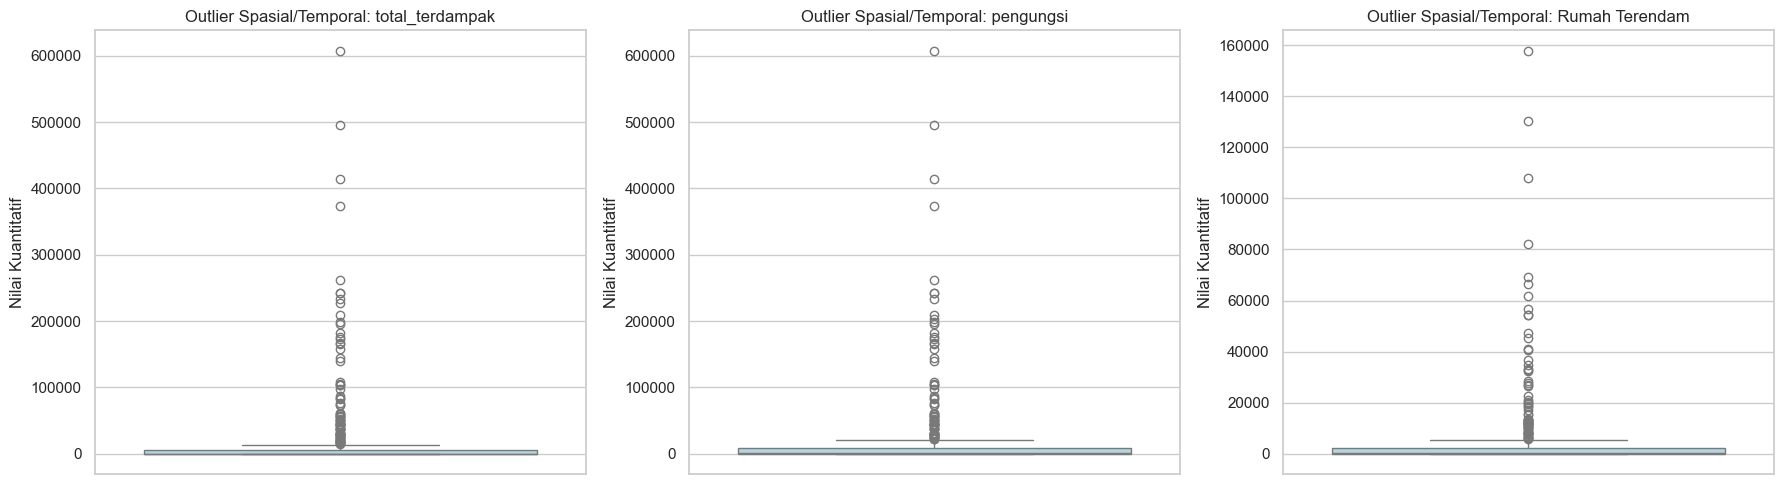

In [8]:

target_cols = ['total_terdampak', 'pengungsi', 'Rumah Terendam']
for col in target_cols:
    if col in df.columns:
        print(f"Skewness Kolom '{col}': {df[col].skew():.2f}")
print("\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(target_cols):
    if col in df.columns:
        sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue')
        axes[i].set_title(f"Outlier Spasial/Temporal: {col}")
        axes[i].set_ylabel("Nilai Kuantitatif")
plt.tight_layout()
plt.show()


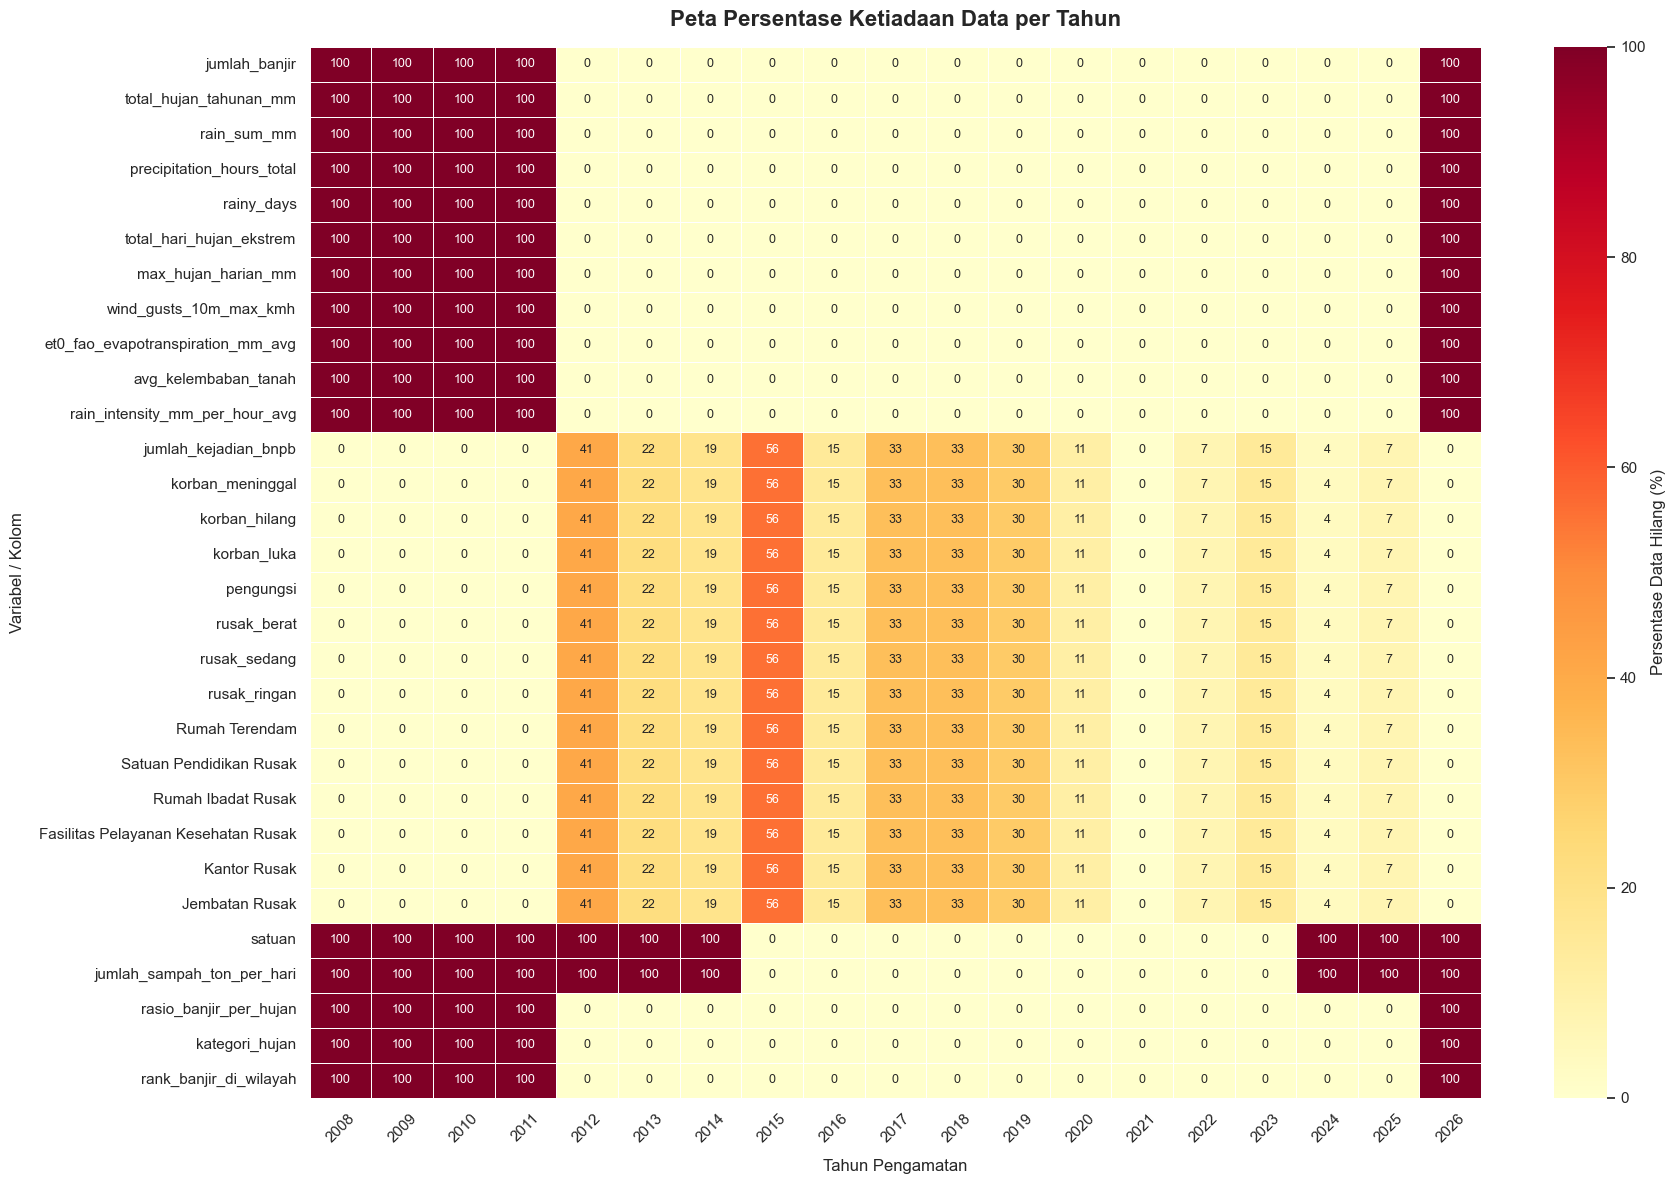

In [16]:
missing_by_year = df.groupby('tahun').apply(lambda x: x.isnull().mean() * 100)

missing_by_year = missing_by_year.T

cols_with_missing = missing_by_year.index[missing_by_year.max(axis=1) > 0]
missing_by_year_filtered = missing_by_year.loc[cols_with_missing]

plt.figure(figsize=(18, 12)) 
sns.heatmap(
    missing_by_year_filtered, 
    annot=True, 
    fmt=".0f",  
    cmap="YlOrRd", 
    linewidths=0.5, 
    cbar_kws={'label': 'Persentase Data Hilang (%)'},
    vmin=0, 
    vmax=100,
    annot_kws={"size": 9} 
)

plt.title("Peta Persentase Ketiadaan Data per Tahun", fontsize=16, pad=15, weight='bold')
plt.xlabel("Tahun Pengamatan", fontsize=12, labelpad=10)
plt.ylabel("Variabel / Kolom", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np

df = pd.read_excel("flood-analytics-jabar.xlsx")
tahun_dibuang = [2008, 2009, 2010, 2011, 2026]
df_clean = df[~df['tahun'].isin(tahun_dibuang)].copy()

print(f"Sisa baris setelah drop tahun: {len(df_clean)} baris")

dampak_cols = [
    'korban_meninggal', 'korban_hilang', 'korban_luka', 'pengungsi', 
    'rusak_berat', 'rusak_sedang', 'rusak_ringan', 'Rumah Terendam', 
    'Satuan Pendidikan Rusak', 'Rumah Ibadat Rusak', 
    'Fasilitas Pelayanan Kesehatan Rusak', 'Kantor Rusak', 
    'Jembatan Rusak', 'total_terdampak', 'jumlah_kejadian_bnpb'
]

for col in dampak_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)


def standardisasi_sampah_tahunan(row):
    if pd.isna(row['jumlah_sampah_ton_per_hari']):
        return np.nan
    elif row['tahun'] in [2015, 2016, 2017]:
        return row['jumlah_sampah_ton_per_hari'] 
    else:
        return row['jumlah_sampah_ton_per_hari'] * 365 

df_clean['jumlah_sampah_ton_per_tahun'] = df_clean.apply(standardisasi_sampah_tahunan, axis=1)
if 'jumlah_sampah_ton_per_hari' in df_clean.columns:
    df_clean.drop(columns=['jumlah_sampah_ton_per_hari'], inplace=True)


df_clean['is_banjir'] = (df_clean['jumlah_banjir'] > 0).astype(int)

def kategori_banjir(val):
    if pd.isna(val):
        return "Data Null"
    elif val == 0:
        return "1 - Tidak Ada Banjir"
    elif val <= 3:
        return "2 - Frekuensi Rendah (1-3x)"
    elif val <= 10:
        return "3 - Frekuensi Sedang (4-10x)"
    else:
        return "4 - Frekuensi Tinggi (>10x)"

df_clean['kategori_intensitas_banjir'] = df_clean['jumlah_banjir'].apply(kategori_banjir)

file_output = "MASTER_MERGED_CLEANED_DASHBOARD.xlsx"
df_clean.to_excel(file_output, index=False)
print(f"Data bersih berhasil disimpan ke {file_output}!")

Sisa baris setelah drop tahun: 378 baris
Data bersih berhasil disimpan ke MASTER_MERGED_CLEANED_DASHBOARD.xlsx!
